# **GARCH vs LSTM**

In [ ]:
!pip install arch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.0/983.0 kB 7.7 MB/s eta 0:00:00


In [ ]:
import yfinance as yf
import math
import numpy as np
import pandas as pd
# Modelos ARCH
from arch import arch_model
from arch.__future__ import reindexing
# Representación de datos
import matplotlib.pyplot as plt
from tabulate import tabulate
# Medidas del error
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
# Red Neuronal LSTM
from keras.models import Sequential
from keras.layers import LSTM, Dense

In [ ]:
empresas = [
    'TSLA', #Tesla
    'GOOG', #Google
    'META', #Meta
    'AMZN', #Amazon
    'MSFT', #Microsoft
    'AAPL', #Apple
]
# Indicar el tipo de volatilidad a predecir en td como:
# 'D' --> Dayly (Diaria) 'W' --> Weekly (Semanal) 'M' --> Monthly (Mensual)

td = 'D' # <--

if (td == 'D'):
  dtime = 'diaria'
  test_size = 150
elif (td == 'W'):
   dtime = 'semanal'
   test_size = 100
else:
  dtime = 'mensual'
  test_size = 50

# Indicar el tamaño de la ventana
N_GARCH = 1
N_LSTM = 150

In [ ]:
# Función creada que convierte los datos de entrada en (i,j)
def convert2matrix(data_arr, look_back):
 X, Y =[], []
 for i in range(len(data_arr)-look_back):
  d=i+look_back
  X.append(data_arr[i:d])
  Y.append(data_arr[d])
 return np.array(X), np.array(Y)

[*********************100%%**********************]  1 of 1 completed
Mejor orden (p, q) según AIC para TSLA: (1, 1)
(98,)
0
Epoch 1/20
50/50 [==============================] - 4s 21ms/step - loss: 45.4490 - val_loss: 51.3151
Epoch 2/20
50/50 [==============================] - 0s 7ms/step - loss: 31.8843 - val_loss: 35.6867
Epoch 3/20
50/50 [==============================] - 0s 5ms/step - loss: 25.4934 - val_loss: 31.2912
Epoch 4/20
50/50 [==============================] - 0s 4ms/step - loss: 24.2231 - val_loss: 30.4510
Epoch 5/20
50/50 [==============================] - 0s 4ms/step - loss: 23.7903 - val_loss: 29.6574
Epoch 6/20
50/50 [==============================] - 0s 4ms/step - loss: 23.5302 - val_loss: 29.1786
Epoch 7/20
50/50 [==============================] - 0s 4ms/step - loss: 23.2729 - val_loss: 28.7121
Epoch 8/20
50/50 [==============================] - 0s 4ms/step - loss: 23.0148 - val_loss: 28.3163
Epoch 9/20
50/50 [==============================] - 0s 4ms/step - loss: 22.

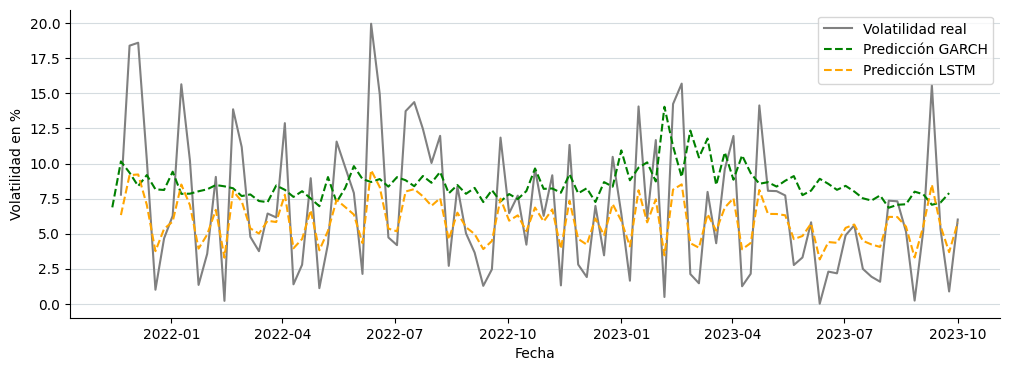

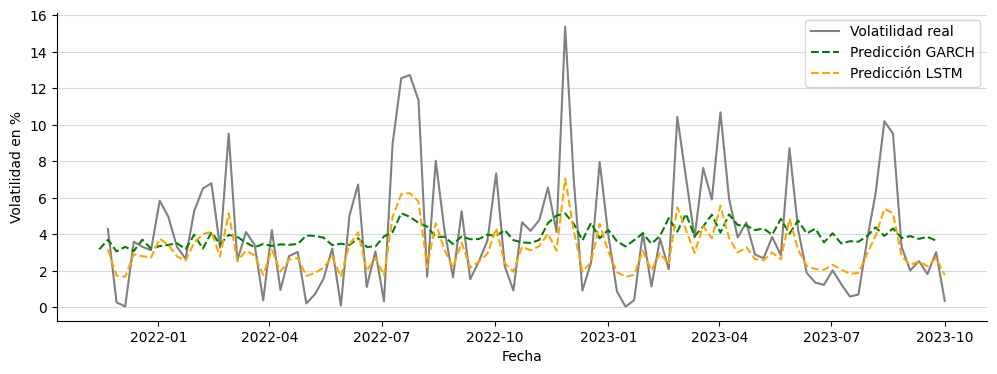

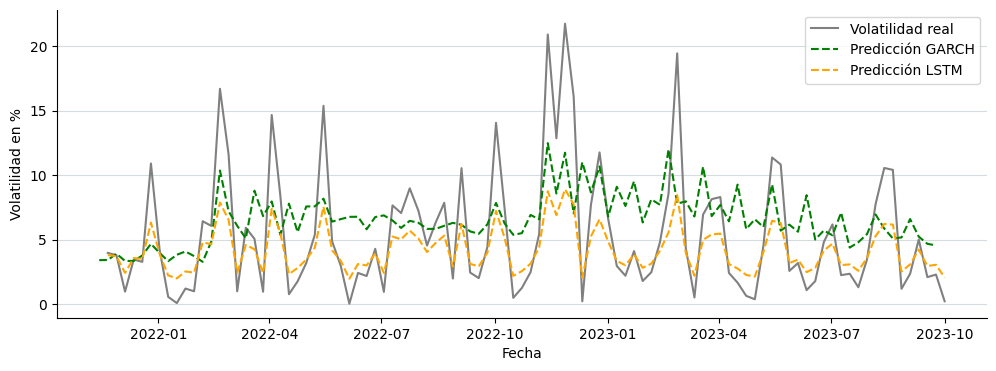

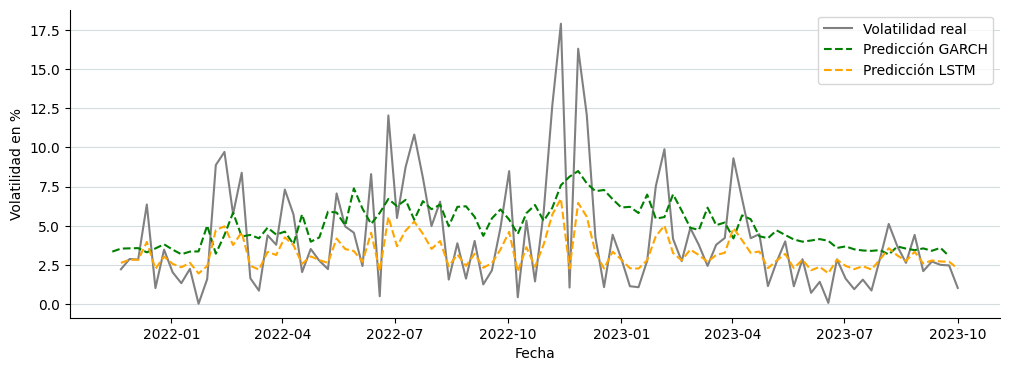

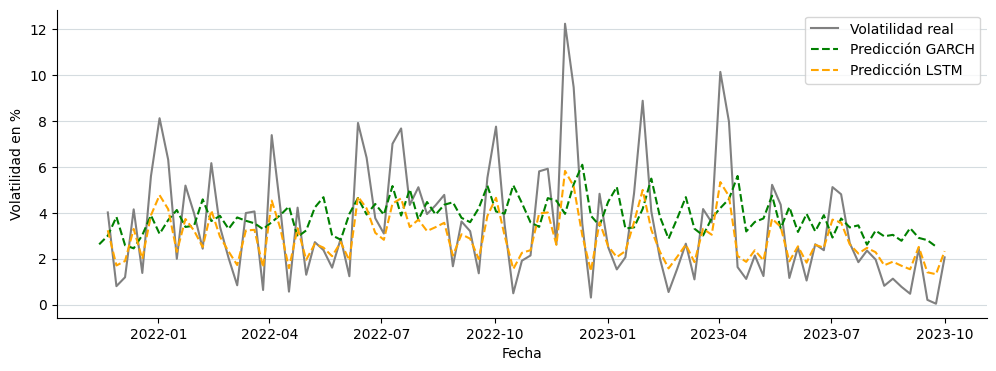

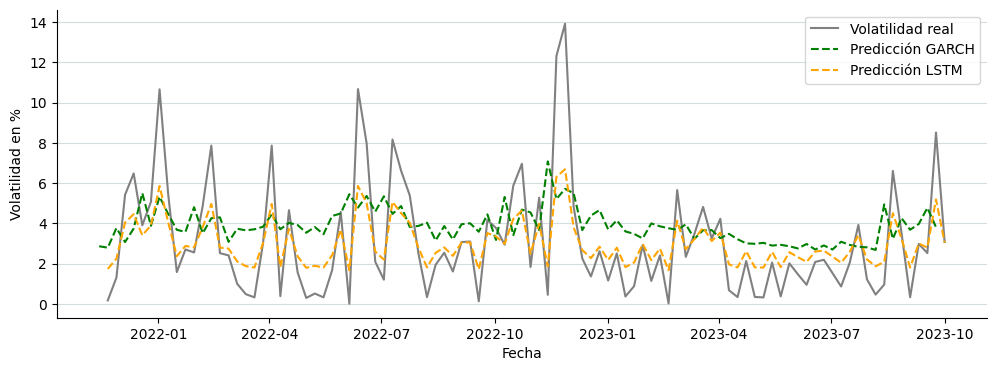

In [ ]:
rent = pd.DataFrame()
for emp in empresas:
  ticker = emp
  data = yf.download(ticker, start="2012-05-18", end="2023-09-30")
  data['R_Log'] = 100*data['Close'].apply(np.log).diff().dropna()
  rent= data['R_Log'].resample(td).sum()
  rentabilidad = rent.replace(0.000000, np.nan).dropna()
  vol = rentabilidad.rolling(window=2).std().dropna()
  best_aic = np.inf

# ------------------------------ GARCH ------------------------------

  # BUCLE DE ESTIMACIÓN DE LOS PARÁMETROS P Y Q
  P, Q = [1,2,3,4], [1,2,3,4]
  for p in P:  # Rango de valores para el componente autoregresivo (p)
    for q in Q:  # Rango de valores para el componente de media móvil (q)
           model = arch_model(rentabilidad, vol='GARCH', p=p, q=q)
           results = model.fit(disp='off')
           aic = results.aic
           if aic < best_aic:
              best_aic = aic
              best_order = (p, q)
  print(f'Mejor orden (p, q) según AIC para {emp}:', best_order)

  # BUCLE DE PREDICCIÓN
  rolling_predictions = []
  # Bucle de predicción
  for i in range(0,test_size,N_GARCH):
      train = rentabilidad[i:-(test_size-i)] # Datos de entrenamiento usando ventana móvil ¿Rentabilidad o Volatilidad como entrada?
      # Definimos y entrenamos el modelo
      model = arch_model(train, p=p, q=q, mean = 'constant', vol = 'GARCH', dist = 'normal')
      model_fit = model.fit(disp='off')
      # Predecimos los N siguientes valores
      pred = model_fit.forecast(horizon=N_GARCH)
      # Calculamos la volatilidad aplicando sqrt a la media de la varianza de los valores predecidos
      rolling_predictions.extend(np.sqrt(pred.variance.values[-1,:]))
  # Transformamos el vector de la volatilidad predicha en una serie con el mismo indice que los retornos diarios
  rolling_predictions = pd.Series(rolling_predictions, index=vol.index[-test_size:])
  rolling_predictions = rolling_predictions.dropna() # Nos aseguramos que los índices coincidan
  print(rolling_predictions[2:].shape)

# ------------------------------ LSTM ------------------------------

  roll_pred = []
  for i in range(0,test_size,N_LSTM):
    print(i)
    train = vol[i:-(test_size-i)]
    if (i == test_size-N_LSTM):
      test = vol[-(test_size-i):]
    else:
      test = vol[-(test_size-i):-(test_size-(i+N_LSTM+1))]
    # Transformamos los datos en matriz 3D
    X = train.dropna()
    X = X.values
    T = test.dropna()
    T = T.values
    xtrain, ytrain = convert2matrix(X,1)
    xtest, ytest = convert2matrix(T,1)
    X_train = xtrain.reshape(xtrain.shape[0],xtrain.shape[1],1)
    Y_train = ytrain
    X_test = xtest.reshape(xtest.shape[0],xtest.shape[1],1)
    Y_test = ytest
    # Definimos y entrenamos el modelo
    model = Sequential()
    model.add(LSTM(128, input_shape=(X_train.shape[1],1), activation='tanh')) # 4, 8, 16, 32, 64
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam', )
    model.fit(X_train, Y_train, epochs=20 ,batch_size = 10, validation_data=(X_test, Y_test))
    # Predecimos lo valores de prueba con el modelo LSTM
    pred = model.predict(X_test)
    roll_pred.extend(pred)

  predictions = [array[0] for array in roll_pred]
  predictions = pd.Series(predictions, index=vol.index[-test_size+1:])
  predictions = predictions.dropna() # Nos aseguramos que los índices coincidan
  vol_moved_lstm = vol[-test_size:].shift(1).dropna()
  predictions =  predictions.shift(1).dropna()

  vol_moved_garch = vol[-test_size-1:].shift(2).dropna() # N=1 --> 2

  # ------------------------------ GRÁFICO ------------------------------

  color_real = 'grey'  # Azul oscuro o verde oscuro
  color_garch = 'green'  # Rojo o naranja
  color_lstm = 'orange'  # Verde o azul claro
  fig,ax = plt.subplots(figsize=(12,4))
  ax.grid(which="major", axis='y', color='#758D99', alpha=0.3, zorder=1)
  ax.spines[['top', 'right']].set_visible(False)
  plt.plot(vol_moved_garch[1:].index, vol_moved_garch[1:], color=color_real, label='Volatilidad Real')
  plt.plot(rolling_predictions[1:-1], color=color_garch, linestyle='--')
  plt.plot(predictions, color=color_lstm, linestyle='--')
  #plt.title(f'Predicción de la volatilidad {dtime} de {ticker}')
  plt.legend(['Volatilidad real','Predicción GARCH','Predicción LSTM'])
  plt.xlabel('Fecha')
  plt.ylabel('Volatilidad en %')

## **GARCH vs EGARCH vs LSTM**

[*********************100%%**********************]  1 of 1 completed


Mejor orden (p, q) según AIC para TSLA: (2, 4)
(148,)
Mejor orden (p, q) según AIC para TSLA: (4, 1)
0
Epoch 1/20
271/271 [==============================] - 4s 6ms/step - loss: 6.6190 - val_loss: 4.3190
Epoch 2/20
271/271 [==============================] - 1s 4ms/step - loss: 5.3823 - val_loss: 4.0498
Epoch 3/20
271/271 [==============================] - 1s 4ms/step - loss: 5.2884 - val_loss: 3.9772
Epoch 4/20
271/271 [==============================] - 1s 4ms/step - loss: 5.2540 - val_loss: 3.9735
Epoch 5/20
271/271 [==============================] - 1s 4ms/step - loss: 5.2612 - val_loss: 3.9084
Epoch 6/20
271/271 [==============================] - 1s 4ms/step - loss: 5.2334 - val_loss: 3.9742
Epoch 7/20
271/271 [==============================] - 1s 4ms/step - loss: 5.2319 - val_loss: 3.8982
Epoch 8/20
271/271 [==============================] - 1s 4ms/step - loss: 5.2412 - val_loss: 3.9452
Epoch 9/20
271/271 [==============================] - 2s 6ms/step - loss: 5.2159 - val_loss: 3.88

[*********************100%%**********************]  1 of 1 completed


Mejor orden (p, q) según AIC para GOOG: (1, 2)
(148,)
Mejor orden (p, q) según AIC para GOOG: (1, 2)
0
Epoch 1/20
271/271 [==============================] - 4s 6ms/step - loss: 1.5211 - val_loss: 1.0016
Epoch 2/20
271/271 [==============================] - 1s 4ms/step - loss: 1.2746 - val_loss: 0.9505
Epoch 3/20
271/271 [==============================] - 1s 4ms/step - loss: 1.2759 - val_loss: 0.9636
Epoch 4/20
271/271 [==============================] - 1s 5ms/step - loss: 1.2666 - val_loss: 0.9607
Epoch 5/20
271/271 [==============================] - 2s 6ms/step - loss: 1.2649 - val_loss: 0.9616
Epoch 6/20
271/271 [==============================] - 1s 5ms/step - loss: 1.2610 - val_loss: 0.9445
Epoch 7/20
271/271 [==============================] - 1s 4ms/step - loss: 1.2584 - val_loss: 0.9854
Epoch 8/20
271/271 [==============================] - 1s 4ms/step - loss: 1.2672 - val_loss: 0.9311
Epoch 9/20
271/271 [==============================] - 1s 4ms/step - loss: 1.2658 - val_loss: 0.92

[*********************100%%**********************]  1 of 1 completed


...

Mejor orden (p, q) según AIC para AMZN: (4, 2)
(148,)
Mejor orden (p, q) según AIC para AMZN: (3, 1)
0
Epoch 1/20
271/271 [==============================] - 4s 8ms/step - loss: 2.0515 - val_loss: 1.6208
Epoch 2/20
271/271 [==============================] - 2s 6ms/step - loss: 1.7586 - val_loss: 1.5873
Epoch 3/20
271/271 [==============================] - 1s 5ms/step - loss: 1.7535 - val_loss: 1.5789
Epoch 4/20
271/271 [==============================] - 1s 5ms/step - loss: 1.7512 - val_loss: 1.6006
Epoch 5/20
271/271 [==============================] - 1s 5ms/step - loss: 1.7418 - val_loss: 1.5467
Epoch 6/20
271/271 [==============================] - 1s 5ms/step - loss: 1.7490 - val_loss: 1.5695
Epoch 7/20
271/271 [==============================] - 1s 4ms/step - loss: 1.7475 - val_loss: 1.5775
Epoch 8/20
271/271 [==============================] - 1s 5ms/step - loss: 1.7437 - val_loss: 1.5581
Epoch 9/20
271/271 [==============================] - 1s 5ms/step - loss: 1.7462 - val_loss: 1.54

[*********************100%%**********************]  1 of 1 completed


Mejor orden (p, q) según AIC para MSFT: (1, 1)
(148,)
Mejor orden (p, q) según AIC para MSFT: (3, 2)
0
Epoch 1/20
269/269 [==============================] - 4s 6ms/step - loss: 1.6018 - val_loss: 1.0470
Epoch 2/20
269/269 [==============================] - 1s 5ms/step - loss: 1.2855 - val_loss: 0.9973
Epoch 3/20
269/269 [==============================] - 1s 4ms/step - loss: 1.2714 - val_loss: 1.0228
Epoch 4/20
269/269 [==============================] - 1s 4ms/step - loss: 1.2510 - val_loss: 0.9975
Epoch 5/20
269/269 [==============================] - 1s 4ms/step - loss: 1.2510 - val_loss: 0.9961
Epoch 6/20
269/269 [==============================] - 1s 4ms/step - loss: 1.2419 - val_loss: 1.0034
Epoch 7/20
269/269 [==============================] - 1s 4ms/step - loss: 1.2412 - val_loss: 0.9787
Epoch 8/20
269/269 [==============================] - 1s 5ms/step - loss: 1.2353 - val_loss: 1.0206
Epoch 9/20
269/269 [==============================] - 2s 7ms/step - loss: 1.2353 - val_loss: 0.97

[*********************100%%**********************]  1 of 1 completed


Mejor orden (p, q) según AIC para AAPL: (1, 1)
(148,)
Mejor orden (p, q) según AIC para AAPL: (1, 1)
0
Epoch 1/20
271/271 [==============================] - 5s 7ms/step - loss: 1.7869 - val_loss: 0.6462
Epoch 2/20
271/271 [==============================] - 1s 4ms/step - loss: 1.4281 - val_loss: 0.6567
Epoch 3/20
271/271 [==============================] - 1s 4ms/step - loss: 1.4126 - val_loss: 0.6081
Epoch 4/20
271/271 [==============================] - 2s 7ms/step - loss: 1.3925 - val_loss: 0.5994
Epoch 5/20
271/271 [==============================] - 2s 6ms/step - loss: 1.3877 - val_loss: 0.5958
Epoch 6/20
271/271 [==============================] - 1s 4ms/step - loss: 1.3668 - val_loss: 0.5556
Epoch 7/20
271/271 [==============================] - 1s 4ms/step - loss: 1.3806 - val_loss: 0.6122
Epoch 8/20
271/271 [==============================] - 1s 4ms/step - loss: 1.3804 - val_loss: 0.5994
Epoch 9/20
271/271 [==============================] - 1s 4ms/step - loss: 1.3690 - val_loss: 0.59

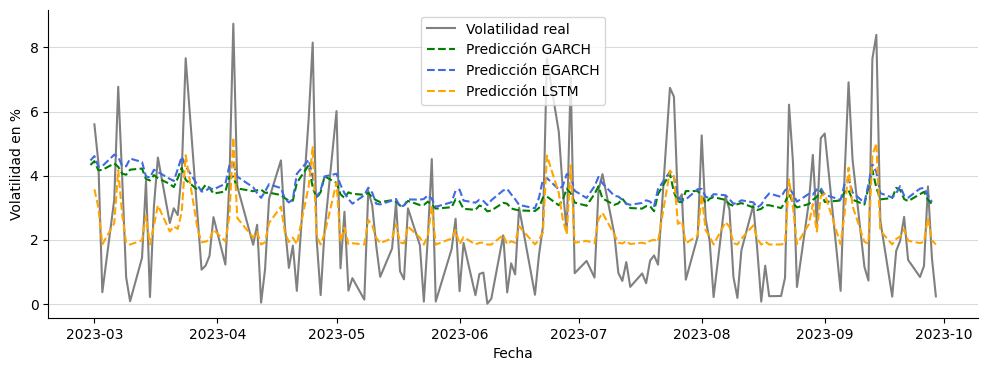

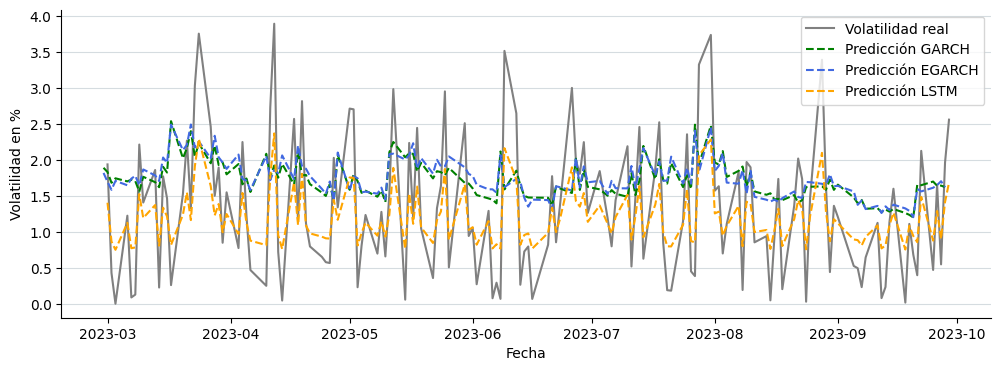

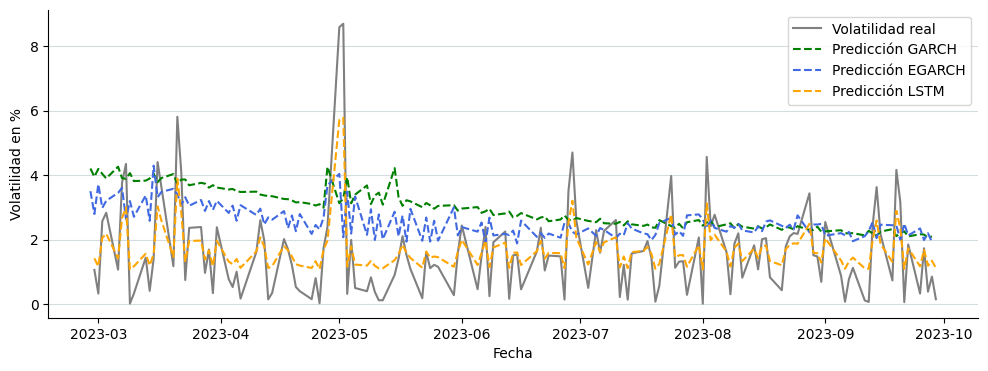

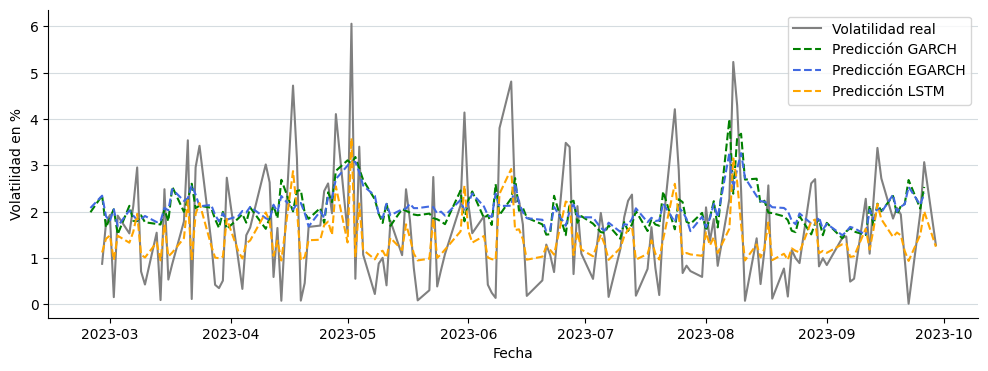

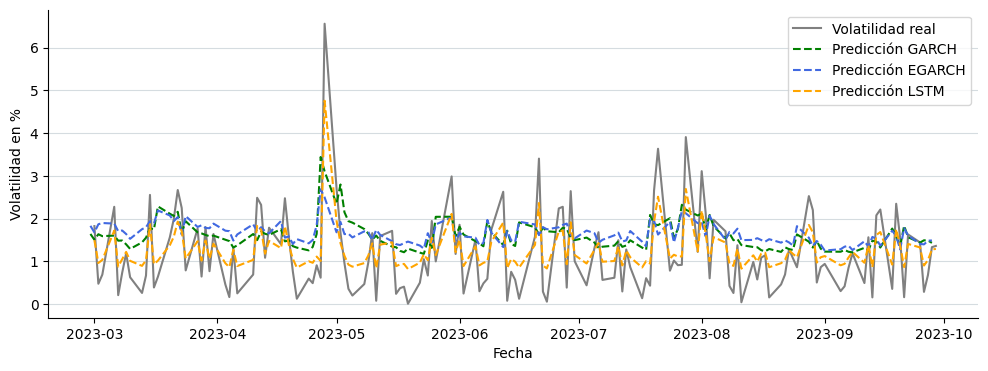

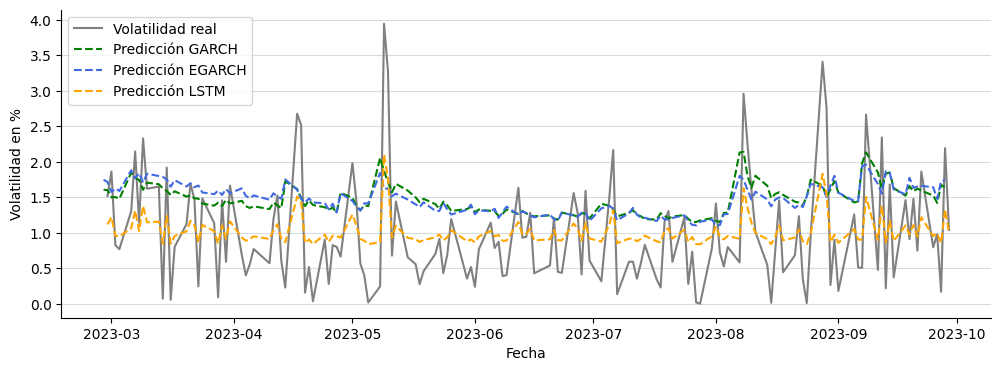

In [ ]:
rent = pd.DataFrame()
for emp in empresas:
  ticker = emp
  data = yf.download(ticker, start="2012-05-18", end="2023-09-30")
  data['R_Log'] = 100*data['Close'].apply(np.log).diff().dropna()
  rent= data['R_Log'].resample(td).sum()
  rentabilidad = rent.replace(0.000000, np.nan).dropna()
  vol = rentabilidad.rolling(window=2).std().dropna()
  best_aic = np.inf
  P, Q = [1,2,3,4], [1,2,3,4]
  for p in P:  # Rango de valores para el componente autoregresivo (p)
    for q in Q:  # Rango de valores para el componente de media móvil (q)
           model = arch_model(rentabilidad, vol='GARCH', p=p, q=q)
           results = model.fit(disp='off')
           aic = results.aic
           if aic < best_aic:
              best_aic = aic
              best_order = (p, q)
  print(f'Mejor orden (p, q) según AIC para {emp}:', best_order)
  # BUCLE DE PREDICCIÓN
  rolling_predictions = []
  # Bucle de predicción
  for i in range(0,test_size,N_GARCH):
      train = rentabilidad[i:-(test_size-i)] # Datos de entrenamiento usando ventana móvil ¿Rentabilidad o Volatilidad como entrada?
      # Definimos y entrenamos el modelo
      model = arch_model(train, p=p, q=q, mean = 'constant', vol = 'GARCH', dist = 'normal')
      model_fit = model.fit(disp='off')
      # Predecimos los N siguientes valores
      pred = model_fit.forecast(horizon=N_GARCH)
      # Calculamos la volatilidad aplicando sqrt a la media de la varianza de los valores predecidos
      rolling_predictions.extend(np.sqrt(pred.variance.values[-1,:]))
  # Transformamos el vector de la volatilidad predicha en una serie con el mismo indice que los retornos diarios
  rolling_predictions = pd.Series(rolling_predictions, index=vol.index[-test_size:])
  rolling_predictions = rolling_predictions.dropna() # Nos aseguramos que los índices coincidan
  print(rolling_predictions[2:].shape)
  # BUCLE DE ESTIMACIÓN DE LOS PARÁMETROS P Y Q
  P, Q = [1,2,3,4], [1,2,3,4]
  for p in P:  # Rango de valores para el componente autoregresivo (p)
    for q in Q:  # Rango de valores para el componente de media móvil (q)
           model = arch_model(rentabilidad, vol='EGARCH', p=p, q=q, o=0)
           results = model.fit(disp='off', options={'maxiter': 1000})
           aic = results.aic
           if aic < best_aic:
              best_aic = aic
              best_order = (p, q)
  print(f'Mejor orden (p, q) según AIC para {emp}:', best_order)
  # BUCLE DE PREDICCIÓN
  rolling_predictions_E = []
  # Bucle de predicción
  for i in range(0,test_size,N_GARCH):
      train = rentabilidad[i:-(test_size-i)] # Datos de entrenamiento usando ventana móvil ¿Rentabilidad o Volatilidad como entrada?
      # Definimos y entrenamos el modelo
      model = arch_model(train, p=p, q=q, o=0, vol = 'EGARCH')
      model_fit = model.fit(disp='off', options={'maxiter': 1000})
      # Predecimos los N siguientes valores
      pred = model_fit.forecast(horizon=N_GARCH)
      # Calculamos la volatilidad aplicando sqrt a la media de la varianza de los valores predecidos
      rolling_predictions_E.extend(np.sqrt(pred.variance.values[-1,:]))
  # Transformamos el vector de la volatilidad predicha en una serie con el mismo indice que los retornos diarios
  rolling_predictions_E = pd.Series(rolling_predictions_E, index=vol.index[-test_size:])
  rolling_predictions_E = rolling_predictions_E.dropna() # Nos aseguramos que los índices coincidan
  roll_pred = []
  for i in range(0,test_size,N_LSTM):
    print(i)
    train = vol[i:-(test_size-i)]
    if (i == test_size-N_LSTM):
      test = vol[-(test_size-i):]
    else:
      test = vol[-(test_size-i):-(test_size-(i+N_LSTM+1))]
    # Transformamos los datos en matriz 3D
    X = train.dropna()
    X = X.values
    T = test.dropna()
    T = T.values
    xtrain, ytrain = convert2matrix(X,1)
    xtest, ytest = convert2matrix(T,1)
    X_train = xtrain.reshape(xtrain.shape[0],xtrain.shape[1],1)
    Y_train = ytrain
    X_test = xtest.reshape(xtest.shape[0],xtest.shape[1],1)
    Y_test = ytest
    # Definimos y entrenamos el modelo
    model = Sequential()
    model.add(LSTM(128, input_shape=(X_train.shape[1],1), activation='tanh')) # 4, 8, 16, 32, 64
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam', )
    model.fit(X_train, Y_train, epochs=20 ,batch_size = 10, validation_data=(X_test, Y_test))
    # Predecimos lo valores de prueba con el modelo LSTM
    pred = model.predict(X_test)
    roll_pred.extend(pred)
  predictions = [array[0] for array in roll_pred]
  predictions = pd.Series(predictions, index=vol.index[-test_size+1:])
  predictions = predictions.dropna() # Nos aseguramos que los índices coincidan
  predictions =  predictions.shift(1).dropna()
  # CALCULO RMSE y MAPE
  vol_moved = vol[-test_size-1:].shift(2).dropna() # N=1 --> 2
  # GRÁFICO PRED vs REAL
  color_real = 'grey'
  color_garch = 'green'
  color_egarch = 'royalblue'
  color_lstm = 'orange'

  fig,ax = plt.subplots(figsize=(12,4))
  ax.grid(which="major", axis='y', color='#758D99', alpha=0.3, zorder=1)
  ax.spines[['top', 'right']].set_visible(False)
  plt.plot(vol_moved[1:].index, vol_moved[1:], color=color_real, label='Volatilidad Real')
  plt.plot(rolling_predictions[1:-1], color=color_garch, linestyle='--')
  plt.plot(rolling_predictions_E[1:-1], color=color_egarch, linestyle='--')
  plt.plot(predictions, color=color_lstm, linestyle='--')
  #plt.title(f'Predicción de la volatilidad {dtime} de {ticker}')
  plt.legend(['Volatilidad real','Predicción GARCH','Predicción EGARCH','Predicción LSTM'])
  plt.xlabel('Fecha')
  plt.ylabel('Volatilidad en %')